# T028 · 激酶相似性：不同视角比较

**注：** 本教程是 TeachOpenCADD 的一部分。TeachOpenCADD 是一个旨在教授领域专用技能，并提供可作为研究项目起点的流程模板的平台。

作者：

- Talia B. Kimber, 2021, [Volkamer 实验室, Charité](https://volkamerlab.org/)
- Dominique Sydow, 2021, [Volkamer 实验室, Charité](https://volkamerlab.org/)
- Andrea Volkamer, 2021, [Volkamer 实验室, Charité](https://volkamerlab.org/)


## 本教程的目标

我们将比较激酶相似性的不同视角，这些视角在前面的 notebook 中已经详细讨论过：

* **教程 T024**：激酶口袋序列（KLIFS 口袋序列）
* **教程 T025**：KiSSim 指纹（激酶结构相似性）
* **教程 T026**：KLIFS 相互作用指纹（IFP）
* **教程 T027**：ChEMBL 生物活性数据（配体谱）

在本教程中，我们重新加载这些距离矩阵，验证它们是否满足距离条件，并比较这些视角在共同激酶子集上的表现。


### _理论_ 部分内容

* 激酶数据集
* 激酶相似性描述符（考虑 4 种不同方法）
* 距离矩阵条件


### _实践_ 部分内容

* 加载激酶相似性和距离矩阵
* 距离矩阵条件
* 可视化示例视角的相似性
  * 将激酶相似性矩阵可视化为热图
  * 将相似性可视化为树状图
* 从四个不同视角可视化相似性
  * 预处理距离矩阵
  * 可视化解读
* 结果分析


### 参考文献

* 激酶数据集：[<i>Molecules</i> (2021), <b>26(3)</b>, 629](https://www.mdpi.com/1420-3049/26/3/629)
* 使用 `scipy` 进行聚类和绘制树状图：https://docs.scipy.org/doc/scipy/reference/cluster.hierarchy.html
* 系统发育树可视化：https://docs.scipy.org/doc/scipy/reference/generated/scipy.cluster.hierarchy.dendrogram.html
* 欧氏距离：https://docs.scipy.org/doc/scipy/reference/generated/scipy.spatial.distance.euclidean.html


In [1]:
import sys

if "google.colab" in sys.modules:
    %pip install teachopencadd --no-deps -q
    !teachopencadd -d 28
    %pip uninstall teachopencadd -y -q
    %pip install -qr requirements.txt

## 理论


### 激酶数据集


我们使用 **教程 T023** 中定义的激酶选择。


### 激酶相似性描述符（考虑 4 种不同方法）

- **教程 T024** = KLIFS 口袋序列
- **教程 T025** = KiSSim 指纹
- **教程 T026** = KLIFS 相互作用指纹
- **教程 T027** = ChEMBL 生物活性数据


### 距离矩阵条件

一个实数方阵 $M \in \mathbb{R}^{n \times n}$ 是距离矩阵的条件是 $M$ 满足以下条件（遵循距离的定义）：

1. a. 非负性：$M_{ij} \geq 0$ 对于所有 $i, j$
   b. 同一性：$M_{ij} = 0 \iff i = j$
2. 对称性：$M_{ij} = M_{ji}$ 对于所有 $i, j$
3. 三角不等式：$M_{ij} \leq M_{ik} + M_{kj}$ 对于所有 $i, j, k$


## 实践


In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.spatial import distance_matrix, distance
from scipy.cluster import hierarchy

In [3]:
HERE = Path(_dh[-1])
DATA = HERE / "data"

### 加载激酶相似性和距离矩阵


我们定义激酶距离矩阵的路径。


In [4]:
kinase_matrix_paths = {
    "sequence": "T024_data",
    "kissim": "T025_data",
    "ifp": "T026_data",
    "ligand-profile": "T027_data",
}

# Distance matrices (for dendrogram)
kinase_distance_matrix_paths = {
    perspective: DATA / folder_name / "kinase_distance_matrix.csv"
    for perspective, folder_name in kinase_matrix_paths.items()
}

我们加载在前面的 notebook 中生成的距离矩阵。


In [5]:
kinase_distance_matrices = {}
for kinsim_perspective, path in kinase_distance_matrix_paths.items():
    kinase_distance_matrices[kinsim_perspective] = pd.read_csv(path, index_col=0).round(6)

### 距离矩阵条件

现在我们创建函数来验证距离条件。


我们检查矩阵的维度：它应该是一个二维的方阵。


In [6]:
def check_dimensionality(matrix):
    """
    Checks whether the input is a 2D array (matrix) and square.

    Parameters
    ----------
    matrix : np.array
        The matrix for which the condition should be checked.

    Returns
    -------
    bool :
        True if the condition is met, False otherwise.
    """
    if len(matrix.shape) != 2:
        raise ValueError(f"The input is not a matrix, but an array of shape {matrix.shape}.")
    elif matrix.shape[0] != matrix.shape[1]:
        raise ValueError(f"The input is not a square matrix. Failing.")
    else:
        return True

我们检查矩阵的所有值是否为正。


In [7]:
def check_positivity(matrix):
    """
    Checks whether all values of a matrix are positive.

    Parameters
    ----------
    matrix : np.array
        The matrix for which the condition should be checked.

    Returns
    -------
    bool :
        True if the condition is met, False otherwise.
    """
    return (matrix >= 0).all()

我们检查矩阵的对角线值是否为零。


In [8]:
def check_null_diagonal(matrix):
    """
    Checks whether the diagonal entries of a matrix are all zero.

    Parameters
    ----------
    matrix : np.array
        The matrix for which the condition should be checked.

    Returns
    -------
    bool :
        True if the condition is met, False otherwise.
    """
    return (np.diagonal(matrix) == 0).all()

我们检查矩阵是否对称。


In [9]:
def check_symmetry(matrix):
    """
    Checks whether a matrix M is symmetric, i.e. M = M^T.

    Parameters
    ----------
    matrix : np.array
        The matrix for which the condition should be checked.

    Returns
    -------
    bool :
        True if the condition is met, False otherwise.
    """
    return (matrix == matrix.transpose()).all()

最后，我们检查三角不等式条件。


In [10]:
def check_triangular_inequality(matrix, tolerance=0.11):
    """
    Checks whether the triangular inequality is met for a matrix,
    i.e. the shortest distance between two points is the straight line.

    Parameters
    ----------
    matrix : np.array
        The matrix for which the condition should be checked.
    tolerance : float
        The accepted tolerance for approximation.

    Returns
    -------
    bool :
        True if the condition is met, False otherwise.
    """
    triang_inequality = None
    for i in range(matrix.shape[0]):
        for j in range(matrix.shape[0]):
            for k in range(matrix.shape[0]):
                if matrix[i, j] <= matrix[i, k] + matrix[k, j] + tolerance:
                    triang_inequality = True
                else:
                    return False
    return triang_inequality

现在我们创建一个函数来组合所有这些条件。


In [11]:
def distance_condition(matrix):
    """
    Checks if all conditions for a matrix are met.

    Parameters
    ----------
    matrix : np.array
        The matrix for which the conditions should be checked.

    Returns
    -------
    None
    """

    dimensionality = check_dimensionality(matrix)
    if dimensionality:
        print(f"{'Dimensionality' : <30}" f"{'Satisfied'}")
    else:
        print(f"{'Dimensionality' : <30}" f"{'Not Satisfied'}")

    positivity = check_positivity(matrix)
    if positivity:
        print(f"{'Postivity' : <30}" f"{'Satisfied'}")
    else:
        print(f"{'Postivity' : <30}" f"{'Satisfied'}")

    diag = check_null_diagonal(matrix)
    if diag:
        print(f"{'Null diagonal' : <30}" f"{'Satisfied'}")
    else:
        print(f"{'Null diagonal' : <30}" f"{'Not Satisfied'}")

    symmetry = check_symmetry(matrix)
    if symmetry:
        print(f"{'Symmetry' : <30}" f"{'Satisfied'}")
    else:
        print(f"{'Symmetry' : <30}" f"{'Satisfied'}")

    triang_inequ = check_triangular_inequality(matrix)
    if triang_inequ:
        print(f"{'Triangular inequality' : <30}" f"{'Satisfied'}")
    else:
        print(f"{'Triangular inequality' : <30}" f"{'Not Satisfied'}")
    print("\n")
    return None

In [12]:
for descriptor, similarity_df in kinase_distance_matrices.items():
    print(f"{descriptor}")
    print("==========")
    x = distance_condition(similarity_df.values)

sequence
Dimensionality                Satisfied
Postivity                     Satisfied
Null diagonal                 Satisfied
Symmetry                      Satisfied
Triangular inequality         Satisfied


kissim
Dimensionality                Satisfied
Postivity                     Satisfied
Null diagonal                 Satisfied
Symmetry                      Satisfied
Triangular inequality         Satisfied


ifp
Dimensionality                Satisfied
Postivity                     Satisfied
Null diagonal                 Satisfied
Symmetry                      Satisfied
Triangular inequality         Satisfied


ligand-profile
Dimensionality                Satisfied
Postivity                     Satisfied
Null diagonal                 Satisfied
Symmetry                      Satisfied
Triangular inequality         Not Satisfied




如果以下检查之一（维度、非负性、零对角线或对称性）失败，则 notebook 的其余部分将无法正常运行，需要重新检查前面 notebook 中的矩阵生成。


### 可视化示例视角的相似性


In [13]:
print(f"Choices of precalculated descriptors: {kinase_distance_matrix_paths.keys()}")

Choices of precalculated descriptors: dict_keys(['sequence', 'kissim', 'ifp', 'ligand-profile'])


我们查看一个示例矩阵：


In [14]:
descriptor_selection = "sequence"

In [15]:
kinase_distance_matrix = kinase_distance_matrices[descriptor_selection]
kinase_distance_matrix

,EGFR,ErbB2,p110a,KDR,BRAF,CDK2,LCK,MET,p38a
EGFR,0.000000,0.059037,0.572938,0.283953,0.344972,0.351553,0.288679,0.288742,0.355356
ErbB2,0.059037,0.000000,0.586362,0.297882,0.345400,0.369692,0.314925,0.302033,0.364827
p110a,0.572938,0.586362,0.000000,0.577295,0.563541,0.576006,0.548664,0.606301,0.568806
KDR,0.283953,0.297882,0.577295,0.000000,0.328732,0.346621,0.312352,0.286194,0.346556
BRAF,0.344972,0.345400,0.563541,0.328732,0.000000,0.353245,0.327067,0.361842,0.362088
CDK2,0.351553,0.369692,0.576006,0.346621,0.353245,0.000000,0.318747,0.343975,0.276907
LCK,0.288679,0.314925,0.548664,0.312352,0.327067,0.318747,0.000000,0.309121,0.337419
MET,0.288742,0.302033,0.606301,0.286194,0.361842,0.343975,0.309121,0.000000,0.370645
p38a,0.355356,0.364827,0.568806,0.346556,0.362088,0.276907,0.337419,0.370645,0.000000


#### 将激酶相似性矩阵可视化为热图

我们以热图形式可视化激酶相似性矩阵。


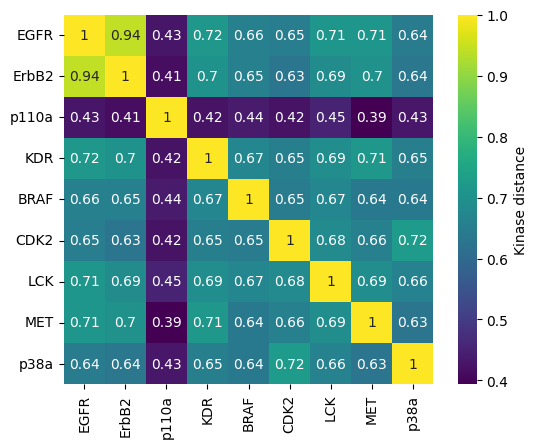

In [16]:
sns.heatmap(
    1 - kinase_distance_matrix,
    linewidths=0,
    annot=True,
    square=True,
    cbar_kws={"label": "Kinase distance"},
    cmap="viridis",
)
plt.show()

#### 将相似性可视化为树状图


由于距离矩阵是对称的，我们使用 `scipy` 函数 `squareform` 创建一个形状为 $n*(n-1)/2$ 的距离矩阵压缩向量，其中 $n$ 是距离矩阵的形状。


In [17]:
D = kinase_distance_matrix.values
D_condensed = distance.squareform(D)
D_condensed

array([0.059037, 0.572938, 0.283953, 0.344972, 0.351553, 0.288679,
       0.288742, 0.355356, 0.586362, 0.297882, 0.3454  , 0.369692,
       0.314925, 0.302033, 0.364827, 0.577295, 0.563541, 0.576006,
       0.548664, 0.606301, 0.568806, 0.328732, 0.346621, 0.312352,
       0.286194, 0.346556, 0.353245, 0.327067, 0.361842, 0.362088,
       0.318747, 0.343975, 0.276907, 0.309121, 0.337419, 0.370645])

我们可以将这个压缩向量提交给层次聚类，以提取不同激酶之间的关系。我们在这里使用 `method="average"`，它代表 UPGMA（非加权对组法）连接方法。


In [18]:
hclust = hierarchy.linkage(D_condensed, method="average")

现在我们基于聚类生成一个系统发育树。


In [19]:
tree = hierarchy.to_tree(hclust)

我们将树可视化为树状图。


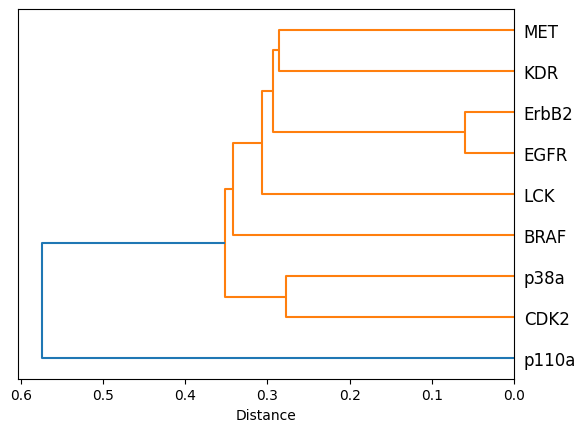

In [20]:
fig, ax = plt.subplots()
labels = kinase_distance_matrix.columns.to_list()
hierarchy.dendrogram(hclust, labels=labels, orientation="left", ax=ax)
ax.set_xlabel("Distance")
plt.show()

### 从四个不同视角可视化相似性


#### 预处理距离矩阵


##### 标准化矩阵

将不同的矩阵标准化为 $[0, 1]$ 范围内的值。


In [21]:
def _min_max_normalize(distance_matrix_df):
    """
    Apply min-max normalization to input DataFrame.

    Parameters
    ----------
    kinase_distance_matrix_df : pd.DataFrame
        Kinase distance matrix.

    Returns
    -------
    pd.DataFrame
        Normalized kinase distance matrix.
    """
    min_ = distance_matrix_df.min().min()
    max_ = distance_matrix_df.max().max()
    distance_matrix_normalized_df = (distance_matrix_df - min_) / (max_ - min_)
    return distance_matrix_normalized_df

In [22]:
kinase_distance_matrices_normalized = {}
for descriptor, score_df in kinase_distance_matrices.items():
    score_normalized_df = _min_max_normalize(score_df)
    kinase_distance_matrices_normalized[descriptor] = score_normalized_df

##### 定义激酶顺序

定义激酶的显示顺序。


In [23]:
kinase_names = kinase_distance_matrices_normalized["sequence"].columns

In [24]:
def _define_kinase_order(kinase_distance_matrix_df, kinase_names, label=""):
    """
    Define the order in which kinases shall
    appear in the input DataFrame.

    Parameters
    ----------
    kinase_distance_matrix_df : pd.DataFrame
        Kinase distance matrix.
    kinase_name : list of str
        List of kinase names to be used for sorting.
    label : str
        Add label for the input matrix.

    Returns
    -------
    pd.DataFrame
        Kinase distance matrix with sorted columns/rows.
    """
    # Remove kinases from ordered kinase set that are not
    # present in input kinase matrix
    kinase_names = [name for name in kinase_names if name in kinase_distance_matrix_df.columns]
    print(f"Kinases present in {label} kinase matrix:\n {kinase_names}")
    # Reorder kinases in matrix
    kinase_distance_matrix_df = kinase_distance_matrix_df.reindex(kinase_names, axis=1).reindex(
        kinase_names, axis=0
    )
    return kinase_distance_matrix_df

In [25]:
kinase_distance_matrices_normalized = {
    descriptor: _define_kinase_order(score_df, kinase_names, descriptor)
    for descriptor, score_df in kinase_distance_matrices_normalized.items()
}

Kinases present in sequence kinase matrix:
 ['EGFR', 'ErbB2', 'p110a', 'KDR', 'BRAF', 'CDK2', 'LCK', 'MET', 'p38a']
Kinases present in kissim kinase matrix:
 ['EGFR', 'ErbB2', 'p110a', 'KDR', 'BRAF', 'CDK2', 'LCK', 'MET', 'p38a']
Kinases present in ifp kinase matrix:
 ['EGFR', 'ErbB2', 'p110a', 'KDR', 'BRAF', 'CDK2', 'LCK', 'MET', 'p38a']
Kinases present in ligand-profile kinase matrix:
 ['EGFR', 'ErbB2', 'p110a', 'KDR', 'BRAF', 'CDK2', 'LCK', 'MET', 'p38a']


#### 可视化解激酶相似性


In [26]:
def heatmap(score_df, ax=None, title=""):
    """
    Generate a heatmap from a matrix.

    Parameters
    ----------
    score_df : pd.DataFrame
        Distance or similarity score matrix.
    ax : matplotlib.axes
        Plot axis to use!
    title : str
        Plot title.
    """
    sns.heatmap(score_df, linewidths=0, annot=True, square=True, cmap="viridis", ax=ax)

In [27]:
def dendrogram(distance_matrix, ax=None, title=""):
    """
    Generate a dendrogram from a distance matrix.

    Parameters
    ----------
    distance_matrix : pd.DataFrame
        Distance matrix.
    ax : matplotlib.axes
        Plot axis to use!
    title : str
        Plot title.
    """
    D = distance_matrix.values
    D_condensed = distance.squareform(D)
    hclust = hierarchy.linkage(D_condensed, method="average")
    tree = hierarchy.to_tree(hclust)
    labels = distance_matrix.columns.to_list()
    hierarchy.dendrogram(hclust, labels=labels, orientation="left", ax=ax)
    ax.set_title(title)
    ax.set_xlabel("Distance")

为便于解释，下面显示的是：

* 基于**相似性**矩阵的热图（值越高，相似性越高）。
* 基于**距离**矩阵计算的树状图。


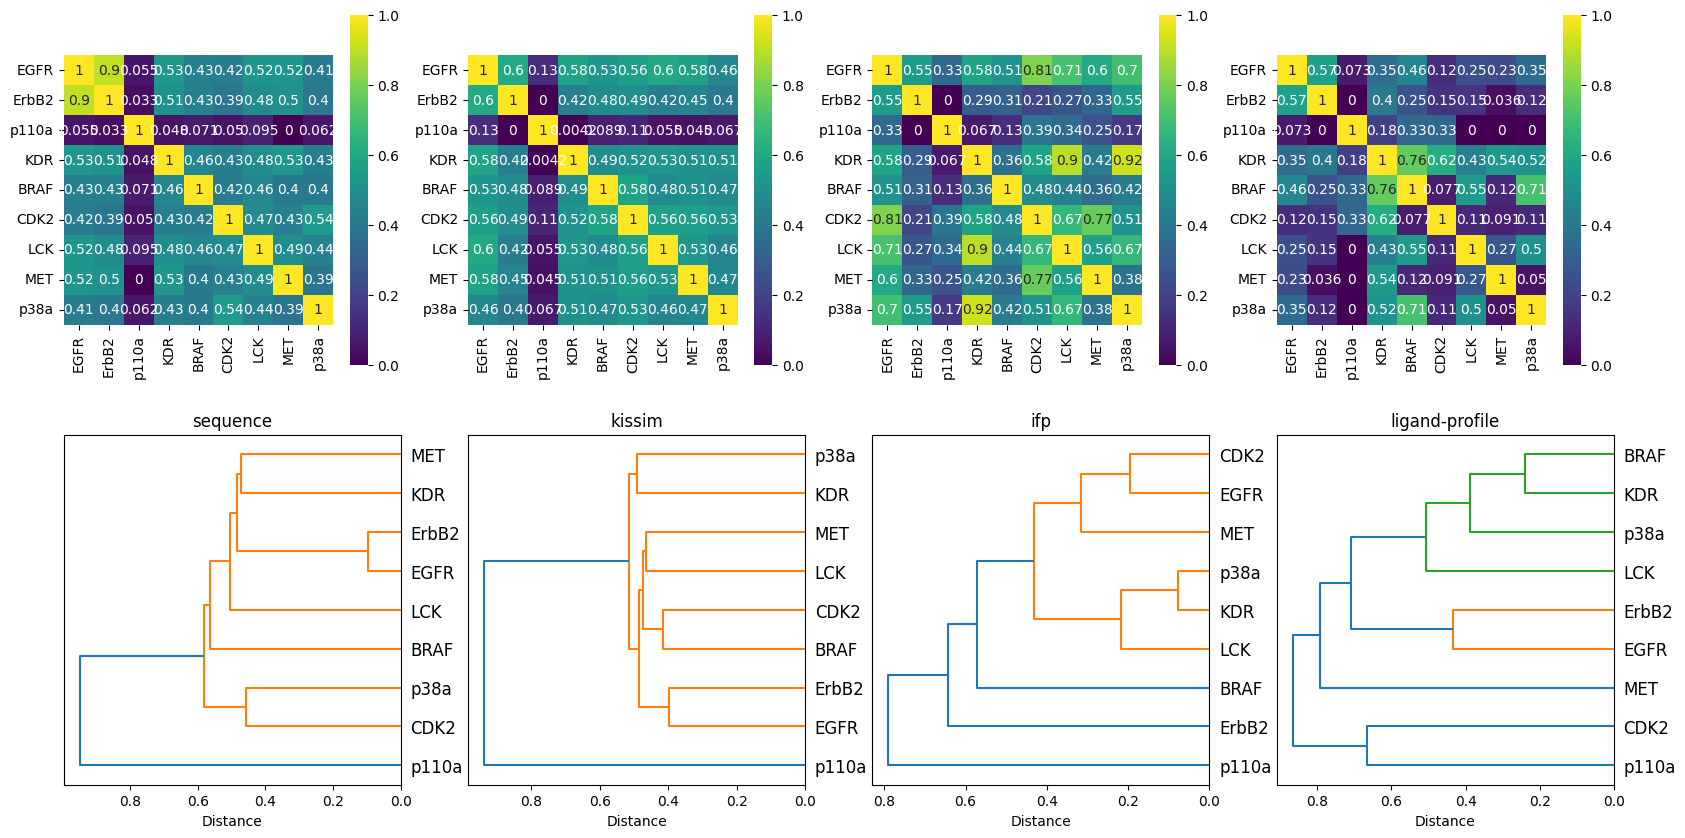

In [28]:
n_perspectives = len(kinase_distance_matrices_normalized)
fig, axes = plt.subplots(2, n_perspectives, figsize=(n_perspectives * 5, 10))
for i, (perspective, distance_matrix) in enumerate(kinase_distance_matrices_normalized.items()):
    # heatmap based on similarity matrix
    similarity_matrix = 1 - distance_matrix
    heatmap(similarity_matrix, ax=axes[0][i], title=perspective)
    # dendrogram based on distance matrix
    dendrogram(distance_matrix, ax=axes[1][i], title=perspective)

我们在此再次加载 **教程 T023** 中定义的输入激酶信息，以确定每个激酶属于哪个组等信息。


In [29]:
kinase_selection_df = pd.read_csv(DATA / "T023_data" / "kinase_selection.csv")
kinase_selection_df

,kinase,kinase_klifs,uniprot_id,group,full_kinase_name
0,EGFR,EGFR,P00533,TK,Epidermal growth factor receptor
1,ErbB2,ErbB2,P04626,TK,Erythroblastic leukemia viral oncogene homolog 2
2,PI3K,p110a,P42336,Atypical,Phosphatidylinositol-3-kinase
3,VEGFR2,KDR,P35968,TK,Vascular endothelial growth factor receptor 2
4,BRAF,BRAF,P15056,TKL,Rapidly accelerated fibrosarcoma isoform B
5,CDK2,CDK2,P24941,CMGC,Cyclic-dependent kinase 2
6,LCK,LCK,P06239,TK,Lymphocyte-specific protein tyrosine kinase
7,MET,MET,P08581,TK,Mesenchymal-epithelial transition factor
8,p38a,p38a,Q16539,CMGC,p38 mitogen activated protein kinase alpha


#### 结果分析

- _序列_方法很好地再现了 Manning 树的关系。
  - TK 激酶 EGFR、ErbB2、MET 和 KDR 被分在一组，EGFR 和 ErbB2 之间的相似性最高（预期中的）。
  - CMGC 激酶 CDK2 和 CDK4 聚集在一起。
  - Other 组激酶 AurA 和 AurB 聚集在一起。
  - p38a 是一个 MAP 激酶（CMGC 组），与 CDK 激酶关系最近。
  - IGF1R 和 INSR（两者都是 TK 组）被归入 TK 组。
- _KiSSim_ 方法也很好地再现了激酶组关系，尽管与序列方法相比分辨率较低。
- _IFP_ 方法部分再现了激酶组关系，但看来配体结合模式不足以说明激酶之间的关系。
- _配体谱_方法无法对激酶组进行良好区分，可能是由于数据稀疏（许多实验数据缺失）。

总体而言，对于这些特定激酶，序列和 KiSSim（结构）方法在区分不同激酶组方面表现良好，而基于配体的方法（IFP 和配体谱）的表现则在某种程度上受到数据可用性的限制。


## 讨论

我们已经从多个不同角度评估了激酶相似性：口袋序列、口袋结构、配体结合模式（相互作用指纹）和配体生物活性。我们看到这些方法在区分不同激酶组方面的效果不同，这取决于数据的可用性和质量。

综上所述，选择哪种激酶相似性度量取决于回答的问题：

* 如果我正在寻找可能结合相似配体的新靶标，我会使用基于配体的相似性度量。
* 如果我对基于已知结构-功能关系的新假设感兴趣，我会使用结构或序列度量。

距离矩阵验证条件有助于评估生成的矩阵是否满足距离度量的要求。然而，在现实世界中，这些条件并不总是能被满足，例如三角不等式条件。在这种情况下，仍然可以使用这些矩阵，但通常需要在应用某些依赖于距离的方法之前修正它们（例如，通过添加一个常数来增强正定性）。更多信息参见 scipy 文档中的 `scipy.spatial.distance.squareform`。


## 测验

1. 你能想到评估激酶相似性的其他视角吗？
2. 还有哪些方法和可视化可以评估相似性？
3. 你能说出每种方法至少一个优点和一个缺点吗？


## 附录

在本附录中，我们为序列视角生成单独的图（热图和树状图）。这些图将保存为 svg 格式。


### 序列热图（svg）


### Sequence heatmap as svg

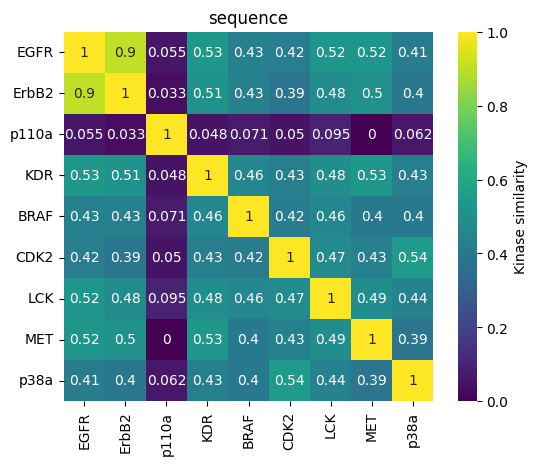

In [30]:
fig, ax = plt.subplots()
sns.heatmap(
    1 - kinase_distance_matrices_normalized["sequence"],
    linewidths=0,
    annot=True,
    square=True,
    cbar_kws={"label": "Kinase similarity"},
    cmap="viridis",
)
plt.title("sequence")
plt.savefig(DATA / "heatmap_sequence.svg")

### 序列树状图（svg）


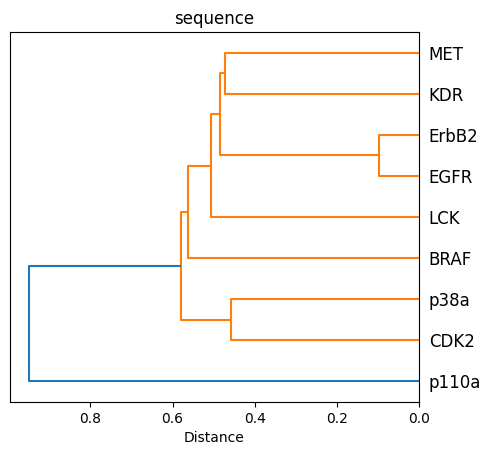

In [31]:
fig, ax = plt.subplots()
D = kinase_distance_matrices_normalized["sequence"].values
D_condensed = distance.squareform(D)
hclust = hierarchy.linkage(D_condensed, method="average")
tree = hierarchy.to_tree(hclust)
labels = distance_matrix.columns.to_list()
hierarchy.dendrogram(hclust, labels=labels, orientation="left", ax=ax)
ax.set_title("sequence")
ax.set_xlabel("Distance")
ax.set_aspect(1 / 100)
plt.savefig(DATA / "dendrogram_sequence.svg")

### 单一比较度量

我们没有使用四种不同的相似性度量，而是计算一个等权重的平均值，以获得一个单一的相似性矩阵（以及相应的热图），该矩阵结合了有关激酶序列、结构和活性的信息。


In [32]:
combined_distance_matrix = (
    sum([distance_matrix for distance_matrix in kinase_distance_matrices_normalized.values()])
    / n_perspectives
)
combined_distance_matrix

,EGFR,ErbB2,p110a,KDR,BRAF,CDK2,LCK,MET,p38a
EGFR,0.000000,0.345073,0.853070,0.488292,0.517561,0.522226,0.480177,0.517406,0.520092
ErbB2,0.345073,0.000000,0.991778,0.595015,0.631776,0.690813,0.670081,0.669546,0.631571
p110a,0.853070,0.991778,0.000000,0.924348,0.845578,0.779110,0.876636,0.926215,0.925134
KDR,0.488292,0.595015,0.924348,0.000000,0.482481,0.463151,0.412795,0.502286,0.405543
BRAF,0.517561,0.631776,0.845578,0.482481,0.000000,0.611584,0.518079,0.654472,0.499924
CDK2,0.522226,0.690813,0.779110,0.463151,0.611584,0.000000,0.545841,0.538301,0.575915
LCK,0.480177,0.670081,0.876636,0.412795,0.518079,0.545841,0.000000,0.535791,0.483474
MET,0.517406,0.669546,0.926215,0.502286,0.654472,0.538301,0.535791,0.000000,0.677882
p38a,0.520092,0.631571,0.925134,0.405543,0.499924,0.575915,0.483474,0.677882,0.000000


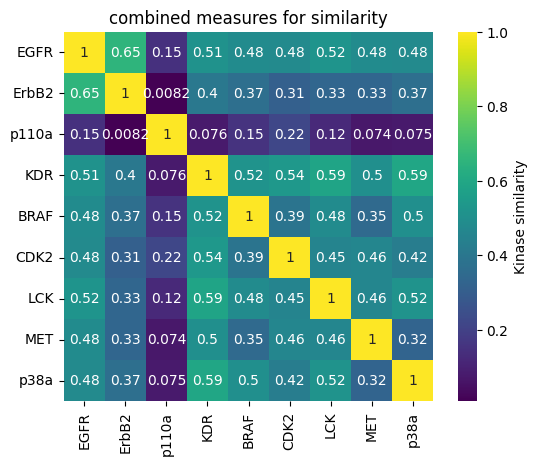

In [33]:
fig, ax = plt.subplots()
sns.heatmap(
    1 - combined_distance_matrix,
    linewidths=0,
    annot=True,
    square=True,
    cbar_kws={"label": "Kinase similarity"},
    cmap="viridis",
)
plt.title("combined measures for similarity")
plt.show()

In [34]:
# In case one or more perspectives have missing kinases,
# the combined distance matrix will contain NaN values
# Remove the missing kinases (and NaN values) from the matrix
# before plotting the dendrogram
combined_distance_matrix = combined_distance_matrix.dropna(axis=0, how="all").dropna(
    axis=1, how="all"
)
combined_distance_matrix

,EGFR,ErbB2,p110a,KDR,BRAF,CDK2,LCK,MET,p38a
EGFR,0.000000,0.345073,0.853070,0.488292,0.517561,0.522226,0.480177,0.517406,0.520092
ErbB2,0.345073,0.000000,0.991778,0.595015,0.631776,0.690813,0.670081,0.669546,0.631571
p110a,0.853070,0.991778,0.000000,0.924348,0.845578,0.779110,0.876636,0.926215,0.925134
KDR,0.488292,0.595015,0.924348,0.000000,0.482481,0.463151,0.412795,0.502286,0.405543
BRAF,0.517561,0.631776,0.845578,0.482481,0.000000,0.611584,0.518079,0.654472,0.499924
CDK2,0.522226,0.690813,0.779110,0.463151,0.611584,0.000000,0.545841,0.538301,0.575915
LCK,0.480177,0.670081,0.876636,0.412795,0.518079,0.545841,0.000000,0.535791,0.483474
MET,0.517406,0.669546,0.926215,0.502286,0.654472,0.538301,0.535791,0.000000,0.677882
p38a,0.520092,0.631571,0.925134,0.405543,0.499924,0.575915,0.483474,0.677882,0.000000


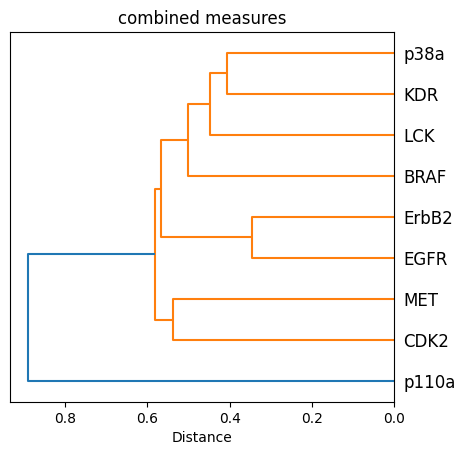

In [35]:
fig, ax = plt.subplots()
D = combined_distance_matrix
D_condensed = distance.squareform(D)
hclust = hierarchy.linkage(D_condensed, method="average")
tree = hierarchy.to_tree(hclust)
labels = combined_distance_matrix.columns.to_list()
hierarchy.dendrogram(hclust, labels=labels, orientation="left", ax=ax)
ax.set_title("combined measures")
ax.set_xlabel("Distance")
ax.set_aspect(1 / 100)